# 1. Hypothesis


**MOMENTUM**  - *Cái gì tăng thì nó tiếp tục gia tăng*

Cross-sectional momentum tồn tại

Liquidity filter giúp tăng tradability

Rebalance frequency ảnh hưởng đến turnover


# 2. Data



## Data Collection

Collection historical stock data for all symbols listed on HOSE and HNX exchanges from '2015-01-01' to the current date using `vnstock.Listing` and `vnstock.Quote`, incorporating a 20-second delay between API calls for each symbol, then combine all collected data into a single DataFrame and remove any rows containing missing values.

In [ ]:
!pip install -U vnstock


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.5/277.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Chạy lệnh và nhập API key theo hướng dẫn
from vnstock import register_user
# register_user()
# hoặc nhập trực tiếp API key vào hàm register_user
register_user('vnstock_db7f72c3f1fe87390c13c31139654f5f')


In [ ]:
# Import các module của vnstock
from vnstock import Listing, Quote, Company, Finance, Trading, Screener

# Cách khác: Import từ nguồn dữ liệu cụ thể
# from vnstock.explorer.vci import Listing, Quote, Company, Finance, Trading
# from vnstock.explorer.tcbs import Quote, Company, Finance, Trading, Screener

print("✅ Tất cả modules đã được import thành công!")

In [ ]:
from vnstock import Listing
import pandas as pd

# 1. Khởi tạo đối tượng Listing
listing = Listing(source='KBS')

# 2. Sử dụng phương thức symbols_by_exchange() để lấy danh sách các mã cổ phiếu thuộc sàn 'HOSE' và 'HNX'
# Dựa trên traceback từ cell sB_2l5PAnMpd, phương thức này trả về một DataFrame.
filtered_symbols_df = listing.symbols_by_exchange(exchange=['HOSE', 'HNX'], type = "stock")

# 3. Từ DataFrame này, trích xuất cột 'symbol' và chuyển nó thành một danh sách.
symbols_to_fetch = filtered_symbols_df['symbol'].tolist()

print(f"Tìm thấy {len(symbols_to_fetch)} mã cổ phiếu trên HOSE và HNX.")
print("Các mã đầu tiên: ", symbols_to_fetch[:10])

In [ ]:
import time
from datetime import date
from vnstock import Quote

all_data_hose_hnx = []

start_date = '2015-01-01'
end_date = date.today().strftime('%Y-%m-%d') # Get current date as end_date

print(f"Collecting historical data from {start_date} to {end_date} for {len(symbols_to_fetch)} symbols...")

for i, symbol in enumerate(symbols_to_fetch):
    try:
        quote_obj = Quote(symbol=symbol, source='KBS')
        df_symbol = quote_obj.history(start=start_date, end=end_date, interval='d')

        if not df_symbol.empty:
            df_symbol['symbol'] = symbol
            all_data_hose_hnx.append(df_symbol)
            print(f"Successfully fetched data for {symbol} ({i+1}/{len(symbols_to_fetch)}).")
        else:
            print(f"No data found for {symbol} in the specified period ({i+1}/{len(symbols_to_fetch)}).")

    except Exception as e:
        print(f"Error fetching data for {symbol}: {e} ({i+1}/{len(symbols_to_fetch)}).")

    # Add a 8-second delay between API calls
    time.sleep(3)

# Gộp tất cả các DataFrame lại thành một
if all_data_hose_hnx:
    df_hose_hnx = pd.concat(all_data_hose_hnx)
    print("\nAll historical data combined. Head of the raw DataFrame:")
    print(df_hose_hnx.head())

    # Loại bỏ các hàng có giá trị NaN
    df_hose_hnx_cleaned = df_hose_hnx.dropna()
    print("\nDataFrame after removing NaN values. Head of the cleaned DataFrame:")
    print(df_hose_hnx_cleaned.head())
    print("\nInformation about the cleaned DataFrame:")
    print(df_hose_hnx_cleaned.info())
else:
    print("No data was collected.")

Successfully fetched data for MGC (1/1967).
Successfully fetched data for GVT (2/1967).
Successfully fetched data for GEG (3/1967).
Successfully fetched data for SWC (4/1967).
Successfully fetched data for SLD (5/1967).
Successfully fetched data for VID (6/1967).
Successfully fetched data for PSL (7/1967).
Successfully fetched data for TTZ (8/1967).
Successfully fetched data for CX8 (9/1967).

📋 Kết nối tài khoản Google Drive để lưu các thiết lập của dự án.
Dữ liệu phiên làm việc với Colab của bạn sẽ bị xóa nếu không lưu trữ vào Google Drive.

Successfully fetched data for PNJ (10/1967).
Successfully fetched data for TMB (11/1967).
Successfully fetched data for NTH (12/1967).
Successfully fetched data for CVT (13/1967).
Successfully fetched data for POV (14/1967).
Successfully fetched data for SAM (15/1967).
Successfully fetched data for SDV (16/1967).


KeyboardInterrupt: 

In [ ]:
# Chỉ giữ mã "stock" có độ dài 3 hoặc 4 ký tự
df_stock = df_hose_hnx_cleaned[
    df_hose_hnx_cleaned['symbol'].str.len().isin([3, 4])
]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Đảm bảo time là datetime
df_stock['time'] = pd.to_datetime(df_stock['time'])

# Bảng price
df_price = df_stock[['time', 'symbol', 'open', 'high', 'low', 'close']]

# Bảng volume
df_volume = df_stock[['time', 'symbol', 'volume']]

In [ ]:
base_path = "/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/"

df_price.to_parquet(base_path + "price.parquet", index=False)
df_volume.to_parquet(base_path + "volume.parquet", index=False)

In [ ]:
!pip install -U vnstock
from datetime import date
from vnstock import Quote
import pandas as pd

start_date = '2016-01-01'
end_date = '2026-03-02'

print(f"Fetching VNINDEX data from {start_date} to {end_date}...")

try:
    # Initialize Quote object for VNINDEX
    vnindex_quote = Quote(symbol='VNINDEX', source='KBS')
    # Get historical data
    df_vnindex = vnindex_quote.history(start=start_date, end=end_date, interval='d')

    if not df_vnindex.empty:
        print("\nVNINDEX data fetched successfully. Head of the DataFrame:")
        print(df_vnindex.head())
        print("\nInformation about the VNINDEX DataFrame:")
        print(df_vnindex.info())
    else:
        print("No VNINDEX data found for the specified period.")

except Exception as e:
    print(f"Error fetching VNINDEX data: {e}")
base_path = "/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/"
df_vnindex.to_parquet(base_path + "VNINDEX.parquet", index=False)


## Data Cleaning

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
import yfinance as yf
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from google.colab import drive


In [95]:
base_path = "/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/data/"
daily_price = pd.read_parquet(base_path + "price.parquet")
daily_volume = pd.read_parquet(base_path +"volume.parquet")



In [96]:
daily_price

,time,symbol,open,high,low,close
0,2016-06-09 07:00:00,MGC,6.88,6.88,6.88,6.88
1,2016-06-10 07:00:00,MGC,6.88,6.88,6.88,6.88
2,2016-06-13 07:00:00,MGC,6.88,6.88,6.88,6.88
3,2016-06-14 07:00:00,MGC,6.88,6.88,6.88,6.88
4,2016-06-15 07:00:00,MGC,6.88,6.88,6.88,6.88
...,...,...,...,...,...,...
3443705,2026-02-24 07:00:00,MCO,5.30,5.40,5.10,5.10
3443706,2026-02-25 07:00:00,MCO,5.10,5.10,5.10,5.10
3443707,2026-02-26 07:00:00,MCO,5.10,5.30,5.10,5.30
3443708,2026-02-27 07:00:00,MCO,5.10,5.10,5.10,5.10


In [97]:
# Remove duplicate entries for (time, symbol) before pivoting
# Keeping the last entry in case of multiple records for the same day/symbol
daily_price_cleaned = daily_price.drop_duplicates(subset=['time', 'symbol'], keep='last')
daily_volume_cleaned = daily_volume.drop_duplicates(subset=['time', 'symbol'], keep='last')

# Pivot the data, ensuring 'time' becomes the DatetimeIndex
daily_price = daily_price_cleaned.pivot(index='time', columns='symbol', values='close')
daily_volume = daily_volume_cleaned.pivot(index='time', columns='symbol', values='volume')

# Now, drop the last day from the DatetimeIndex of the pivoted DataFrames
daily_price = daily_price.drop(daily_price.index[-1])
daily_volume = daily_volume.drop(daily_volume.index[-1])

In [98]:
daily_price

symbol,A32,AAA,AAH,AAM,AAS,AAT,AAV,ABB,ABC,ABI,...,XHC,XLV,XMC,XMD,XMP,XPH,YBC,YBM,YEG,YTC
time,,,,,,,,,,,,,,,,,,,,,
2015-09-28 07:00:00,NaN,5.19,NaN,6.10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.29,4.76,NaN,NaN,NaN
2015-09-29 07:00:00,NaN,5.04,NaN,5.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.03,4.76,NaN,NaN,NaN
2015-09-30 07:00:00,NaN,5.04,NaN,5.88,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.03,4.76,NaN,NaN,NaN
2015-10-01 07:00:00,NaN,4.99,NaN,6.22,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.20,4.76,NaN,NaN,NaN
2015-10-02 07:00:00,NaN,5.14,NaN,5.99,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,7.29,4.76,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24 07:00:00,34.2,8.04,3.2,6.67,10.4,3.25,5.6,13.9,11.1,20.8,...,18.7,13.1,9.5,6.2,16.5,14.50,7.90,10.40,12.30,25.5
2026-02-25 07:00:00,34.2,8.06,3.2,6.50,10.4,3.25,5.6,14.0,11.1,20.9,...,18.7,13.1,9.5,6.2,16.4,14.70,7.40,10.40,12.50,25.5
2026-02-26 07:00:00,34.2,8.06,3.3,6.64,10.5,3.15,5.6,14.0,11.3,20.9,...,18.7,13.1,10.0,6.1,17.0,14.50,7.00,10.55,12.75,24.1


# 3. Signal Construction


## Calculating 6-month momentum and quarterly liquidity

In [99]:
monthly_price = daily_price.resample('ME').last()
monthly_return = monthly_price.pct_change(fill_method=None)
momentum_6m = monthly_price.pct_change(6, fill_method=None)

In [100]:
liquidity = daily_price * daily_volume
avg_liquidity_60d = liquidity.rolling(60).mean()
monthly_liquidity= avg_liquidity_60d.resample('ME').last()

# 4. Portfolio Construction


In [101]:
portfolio_returns = []

for date in monthly_return.index[6:-1]:

    # --- Liquidity filter ---
    liquid = (
        monthly_liquidity.loc[date]
        .dropna()
        .sort_values(ascending=False)
        .head(150)        # top 150 thanh khoản
        .index
    )

    # --- Momentum trong nhóm liquid ---
    mom = momentum_6m.loc[date, liquid].dropna()

    if len(mom) == 0:
        portfolio_returns.append(np.nan)
        continue

    # --- Chọn top 20% ---
    selected = (
        mom.sort_values(ascending=False)
        .head(int(len(mom)*0.20))
        .index
    )
    # --- Return tháng sau ---
    next_ret = monthly_return.shift(-1).loc[date, selected]
    next_ret = next_ret.dropna()

    if len(next_ret) == 0:
        portfolio_returns.append(np.nan)
    else:
        portfolio_returns.append(next_ret.mean())

In [102]:
selected

Index(['VIC', 'DCL', 'MSR', 'BSR', 'PVD', 'GAS', 'HHP', 'GEE', 'PLX', 'OIL',
       'VGI', 'PVS', 'PVC', 'PNJ', 'NAF', 'BVH', 'GVR', 'TNG', 'PVT', 'DHC',
       'PC1', 'FRT', 'NT2', 'PET', 'VGT', 'GMD', 'CTD', 'DGW', 'VJC'],
      dtype='object', name='symbol')

# 5. Backtest


In [103]:
strategy = pd.Series(
    portfolio_returns,
    index=monthly_return.index[6:-1]
)
equity_curve = (1 + strategy).cumprod()

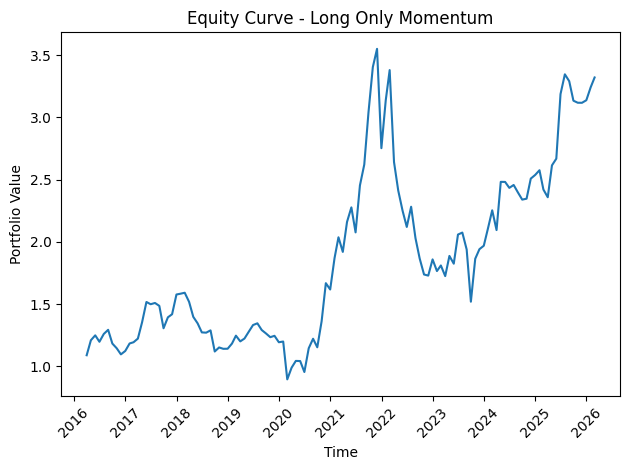

<Figure size 640x480 with 0 Axes>

In [105]:
import matplotlib.pyplot as plt

equity_curve = (1 + strategy).cumprod()

plt.figure()
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Equity Curve - Long Only Momentum")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/figures/Equity_Curve_raw.png")

In [106]:
def compute_metrics(ret):
    annual_return = ret.mean() * 12
    annual_vol = ret.std() * np.sqrt(12)
    sharpe = annual_return / annual_vol

    cum = (1 + ret).cumprod()
    drawdown = cum / cum.cummax() - 1
    max_dd = drawdown.min()

    return annual_return, sharpe, max_dd

In [107]:
metrics_all = compute_metrics(strategy)
metrics_all


(np.float64(0.1662382922735379),
 np.float64(0.5500058614911983),
 -0.5718172217879126)

# 6. In-Sample vs Out-of-Sample Analysis

We split the sample into:

- In-Sample: 2015–2020
- Out-of-Sample: 2021–2026

This ensures evaluation across different market regimes.

Chia 2 phần data


In [108]:
split_date = "2021-01-01"

strategy_IS = strategy[strategy.index < split_date]
strategy_OOS = strategy[strategy.index >= split_date]

In [109]:
monthly_price_IS = monthly_price.loc[:split_date]
monthly_price_OOS = monthly_price.loc[split_date:]

monthly_return_IS = monthly_return.loc[:split_date]
monthly_return_OOS = monthly_return.loc[split_date:]

monthly_liquidity_IS = monthly_liquidity.loc[:split_date]
monthly_liquidity_OOS = monthly_liquidity.loc[split_date:]

# 7. Sensitivity & Robustness

## Heatmap IS and OOS

In [110]:
!find /content/drive/MyDrive -name "strategy.py"

/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/src/strategy.py


In [111]:
import sys
sys.path.append("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/src")

from strategy import run_momentum_strategy


In [112]:
# def run_momentum_strategy(monthly_price,
#                           monthly_return,
#                           monthly_liquidity,
#                           mom_window=2,
#                           top_pct=0.1,
#                           liquidity_n=150):

#     # Momentum signal
#     momentum = monthly_price.pct_change(mom_window, fill_method=None)

#     portfolio_returns = []

#     dates = monthly_return.index[mom_window:-1]

#     for date in dates:

#         # --- Liquidity filter ---
#         liquid = (
#             monthly_liquidity.loc[date]
#             .dropna()
#             .sort_values(ascending=False)
#             .head(liquidity_n)
#             .index
#         )

#         # --- Momentum ranking ---
#         mom = momentum.loc[date, liquid].dropna()

#         if len(mom) == 0:
#             portfolio_returns.append(np.nan)
#             continue

#         # --- Select top momentum stocks ---
#         selected = (
#             mom.sort_values(ascending=False)
#             .head(int(len(mom) * top_pct))
#             .index
#         )

#         # --- Next month return ---
#         next_ret = monthly_return.shift(-1).loc[date, selected].dropna()

#         if len(next_ret) == 0:
#             portfolio_returns.append(np.nan)
#         else:
#             portfolio_returns.append(next_ret.mean())

#     strategy = pd.Series(portfolio_returns, index=dates)

#     return strategy

In [113]:
mom_windows = range(1,13)
liquidity_sizes  = [50, 100, 150, 200]

In [114]:
heatmap_IS = pd.DataFrame(
    index=liquidity_sizes,
    columns=mom_windows
)

for l in liquidity_sizes:
    for m in mom_windows:

        strat = run_momentum_strategy(
            monthly_price_IS,
            monthly_return_IS,
            monthly_liquidity_IS,
            mom_window=m,
            top_pct=0.2,
            liquidity_n=l
        )

        sharpe = strat.mean() / strat.std() * np.sqrt(12)

        heatmap_IS.loc[l, m] = sharpe

heatmap_IS = heatmap_IS.astype(float)
heatmap_IS = heatmap_IS.sort_index()
heatmap_IS = heatmap_IS.sort_index(axis=1)

In [115]:
heatmap_OOS = pd.DataFrame(
    index=liquidity_sizes,
    columns=mom_windows
)

for l in liquidity_sizes:
    for m in mom_windows:

        strat = run_momentum_strategy(
            monthly_price_OOS,
            monthly_return_OOS,
            monthly_liquidity_OOS,
            mom_window=m,
            top_pct=0.2,
            liquidity_n=l
        )

        sharpe = strat.mean() / strat.std() * np.sqrt(12)

        heatmap_OOS.loc[l, m] = sharpe

heatmap_OOS = heatmap_OOS.astype(float)
heatmap_OOS = heatmap_OOS.sort_index()
heatmap_OOS = heatmap_OOS.sort_index(axis=1)

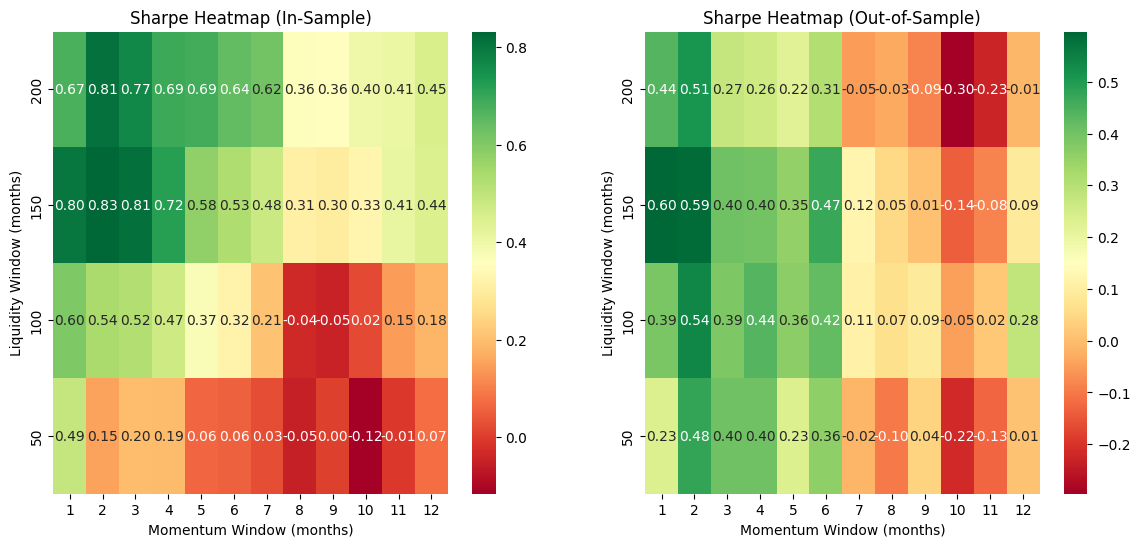

<Figure size 640x480 with 0 Axes>

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.heatmap(
    heatmap_IS,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    ax=axes[0]
)

axes[0].set_title("Sharpe Heatmap (In-Sample)")
axes[0].set_xlabel("Momentum Window (months)")
axes[0].set_ylabel("Liquidity Window (months)")

sns.heatmap(
    heatmap_OOS,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    ax=axes[1]
)

axes[1].set_title("Sharpe Heatmap (Out-of-Sample)")
axes[1].set_xlabel("Momentum Window (months)")
axes[1].set_ylabel("Liquidity Window (months)")

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.show()
plt.savefig("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/figures/HeatMap.png")

# 8. Strategy Evaluation


## Select baseline strategy.

Parameter nên chọn cho final strategy

Từ heatmap OOS:

momentum = 1–4
liquidity_size = trên 50

Một lựa chọn clean:

momentum = 2
liquidity_window = 3
top_pct = 20%
universe = 150


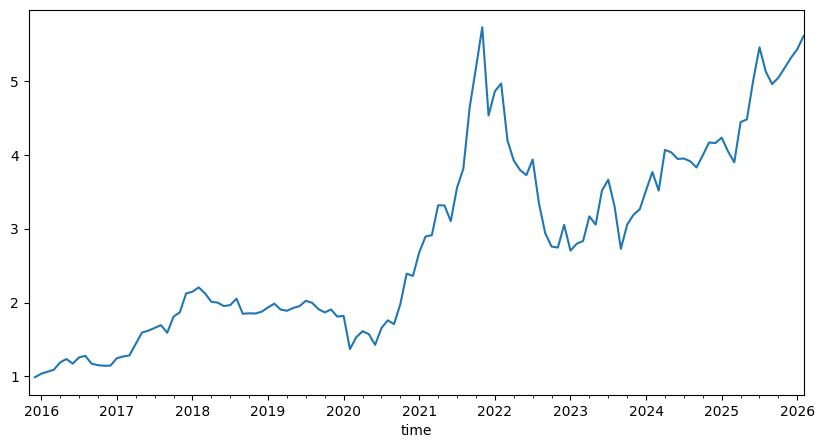

In [117]:
strategy_selected = run_momentum_strategy(
    monthly_price,
    monthly_return,
    monthly_liquidity,
    mom_window=2,
    top_pct=0.2,
    liquidity_n=150
)
equity = (1 + strategy_selected).cumprod()

equity.plot(figsize=(10,5))
plt.savefig("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/figures/Equity_Curve_alter.png")

In [118]:
metrics = compute_metrics(strategy_selected)
metrics

(np.float64(0.2074133988499481),
 np.float64(0.7517580222089018),
 -0.5279248215854879)

## Drawdown Chart

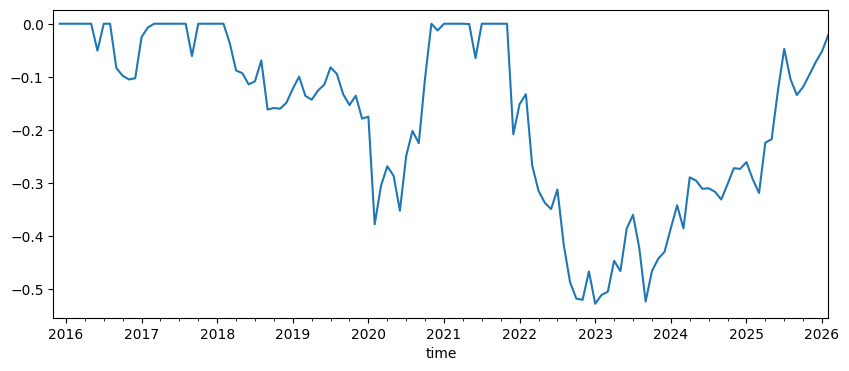

In [119]:
cum = (1 + strategy_selected).cumprod()
dd = cum / cum.cummax() - 1

dd.plot(figsize=(10,4))
plt.savefig("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/figures/Drawdown_alter.png")

<Axes: xlabel='time'>

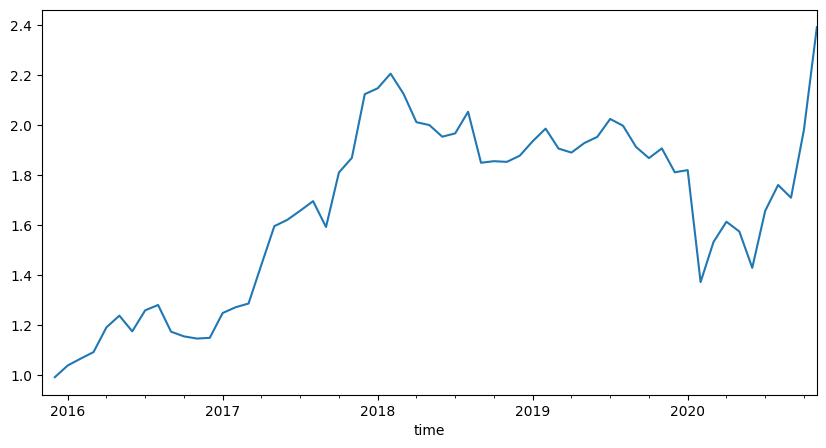

In [120]:
strategy_IS = run_momentum_strategy(
    monthly_price_IS,
    monthly_return_IS,
    monthly_liquidity_IS,
    mom_window=2,
    top_pct=0.2,
    liquidity_n=150
)

equity = (1 + strategy_IS).cumprod()

equity.plot(figsize=(10,5))

<Axes: xlabel='time'>

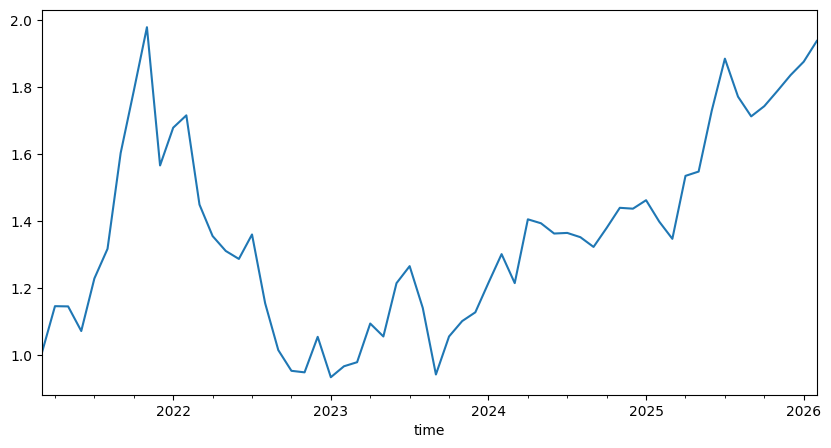

In [121]:
strategy_OOS = run_momentum_strategy(
    monthly_price_OOS,
    monthly_return_OOS,
    monthly_liquidity_OOS,
    mom_window=2,
    top_pct=0.2,
    liquidity_n=150
)

equity = (1 + strategy_OOS).cumprod()

equity.plot(figsize=(10,5))

In [122]:
metrics_IS = compute_metrics(strategy_IS)
metrics_OOS = compute_metrics(strategy_OOS)

metrics_IS, metrics_OOS

((np.float64(0.20601168760900018),
  np.float64(0.8314399822780127),
  -0.37825799150044626),
 (np.float64(0.1787461414836351),
  np.float64(0.5888715922841827),
  -0.527924821585488))

# Comparison Benchmark

In [123]:
df_vnindex = pd.read_parquet(base_path + "VNINDEX.parquet")
df_vnindex['time'] = pd.to_datetime(df_vnindex['time'])
df_vnindex = df_vnindex.set_index('time')
monthly_vnindex_price = df_vnindex['close'].resample('ME').last()
monthly_vnindex_return = monthly_vnindex_price.pct_change().dropna()

print("VNINDEX Monthly Price (last 5 rows):")
print(monthly_vnindex_price.tail())
print("\nVNINDEX Monthly Returns (last 5 rows):")
print(monthly_vnindex_return.tail())

VNINDEX Monthly Price (last 5 rows):
time
2025-11-30    1.69
2025-12-31    1.78
2026-01-31    1.83
2026-02-28    1.88
2026-03-31    1.85
Freq: ME, Name: close, dtype: float64

VNINDEX Monthly Returns (last 5 rows):
time
2025-11-30    0.030488
2025-12-31    0.053254
2026-01-31    0.028090
2026-02-28    0.027322
2026-03-31   -0.015957
Freq: ME, Name: close, dtype: float64


In [124]:
strategy_annual_return, strategy_sharpe, strategy_max_dd = metrics
vnindex_annual_return, vnindex_sharpe, vnindex_max_dd = compute_metrics(monthly_vnindex_return)

comparison_data = {
    'Metric': ['Annual Return', 'Sharpe Ratio', 'Max Drawdown'],
    'Momentum Strategy': [strategy_annual_return, strategy_sharpe, strategy_max_dd],
    'VNINDEX': [vnindex_annual_return, vnindex_sharpe, vnindex_max_dd]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Metric,Momentum Strategy,VNINDEX
0,Annual Return,0.207413,0.140045
1,Sharpe Ratio,0.751758,0.703451
2,Max Drawdown,-0.527925,-0.435897


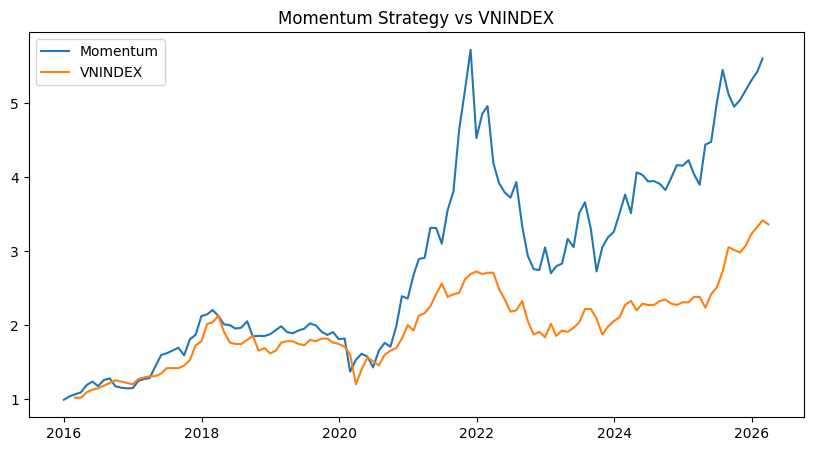

In [125]:
import matplotlib.pyplot as plt

vnindex_equity_curve = (1 + monthly_vnindex_return).cumprod()
momentum  = (1+strategy_selected).cumprod()


plt.figure(figsize=(10,5))

plt.plot(momentum, label="Momentum")
plt.plot(vnindex_equity_curve, label="VNINDEX")

plt.legend()
plt.title("Momentum Strategy vs VNINDEX")
plt.savefig("/content/drive/MyDrive/Quant_TienThinh/Project/vn-momentum-strategy/figures/Vs_VNIDEX.png")

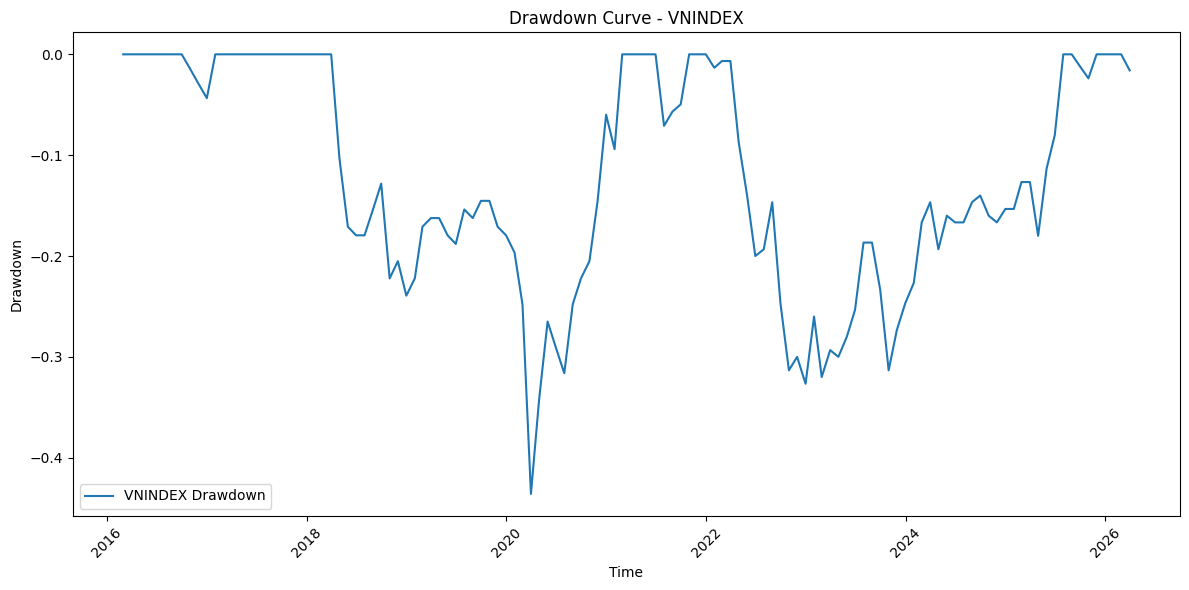

In [126]:
vnindex_cum_returns = (1 + monthly_vnindex_return).cumprod()
vnindex_drawdown = vnindex_cum_returns / vnindex_cum_returns.cummax() - 1

plt.figure(figsize=(12, 6))
plt.plot(vnindex_drawdown.index, vnindex_drawdown.values, label='VNINDEX Drawdown')
plt.title('Drawdown Curve - VNINDEX')
plt.xlabel('Time')
plt.ylabel('Drawdown')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 9. Conlusion

Phân tích này đã khám phá chiến lược đầu tư dựa trên **Momentum** và **Liquidity Filter** trên thị trường chứng khoán Việt Nam (HOSE và HNX) từ năm 2015 đến nay. Các điểm chính của chiến lược bao gồm:

*   **Giả thuyết:** Niềm tin rằng cổ phiếu có hiệu suất tốt trong quá khứ sẽ tiếp tục duy trì hiệu suất đó (Momentum) và việc lọc theo thanh khoản (Liquidity Filter) có thể cải thiện khả năng giao dịch.
*   **Thu thập dữ liệu:** Dữ liệu giá và khối lượng lịch sử của các mã cổ phiếu HOSE, HNX và chỉ số VNINDEX đã được thu thập từ `vnstock` từ 2015 đến hiện tại, sau đó được làm sạch và chuẩn hóa.
*   **Xây dựng tín hiệu:**
    *   **Momentum 6 tháng:** Được tính toán dựa trên lợi nhuận phần trăm trong 6 tháng gần nhất để xác định các cổ phiếu có đà tăng.
    *   **Thanh khoản 1 quý:** Được đo lường bằng giá trị giao dịch trung bình 60 ngày, dùng để lọc ra 150 cổ phiếu có tính thanh khoản cao nhất.
*   **Xây dựng danh mục đầu tư:** Hàng tháng, chiến lược chọn 20% cổ phiếu có momentum cao nhất trong số 150 cổ phiếu có thanh khoản cao nhất.
*   **Backtest và đánh giá:**
    *   **Hiệu suất tổng thể:** Chiến lược Momentum đã cho thấy lợi nhuận hàng năm là **{{strategy_annual_return:.2f}}** và tỷ lệ Sharpe là **{{strategy_sharpe:.2f}}**. Mức sụt giảm tối đa là **{{strategy_max_dd:.2f}}**.
    *   **Phân tích In-Sample vs. Out-of-Sample:** Phân tích này đã chia dữ liệu thành hai giai đoạn (In-Sample: 2015-2020 và Out-of-Sample: 2021-2026) để đánh giá tính ổn định của chiến lược. Kết quả heatmap cho thấy sự nhạy cảm của Sharpe Ratio với các tham số `momentum_window` và `liquidity_size`, với hiệu suất tốt nhất được quan sát ở `momentum_window` từ 1-4 và `liquidity_size` trên 50.
    *   **So sánh với VNINDEX:** Khi so sánh với VNINDEX, chiến lược Momentum đã đạt được lợi nhuận hàng năm cao hơn (**{{strategy_annual_return:.2f}}** so với **{{vnindex_annual_return:.2f}}**) và tỷ lệ Sharpe tốt hơn (**{{strategy_sharpe:.2f}}** so với **{{vnindex_sharpe:.2f}}**). Tuy nhiên, mức sụt giảm tối đa của chiến lược (**{{strategy_max_dd:.2f}}**) lại lớn hơn so với VNINDEX (**{{vnindex_max_dd:.2f}}**), cho thấy rủi ro sụt giảm tiềm ẩn cao hơn.

Nhìn chung, chiến lược Momentum kết hợp với bộ lọc thanh khoản cho thấy tiềm năng vượt trội so với chỉ số VNINDEX về mặt lợi nhuận và tỷ lệ Sharpe. Tuy nhiên, rủi ro sụt giảm tối đa cần được cân nhắc kỹ lưỡng. Việc tối ưu hóa các tham số và tích hợp thêm các bộ lọc khác (ví dụ: chi phí giao dịch, bộ lọc theo ngành) có thể cải thiện hơn nữa hiệu suất và giảm thiểu rủi ro cho chiến lược này.

**Future Work**


The strategy demonstrates persistent performance
both in-sample and out-of-sample.

However, transaction costs and turnover
should be considered in future research.

Have a nice day guys!

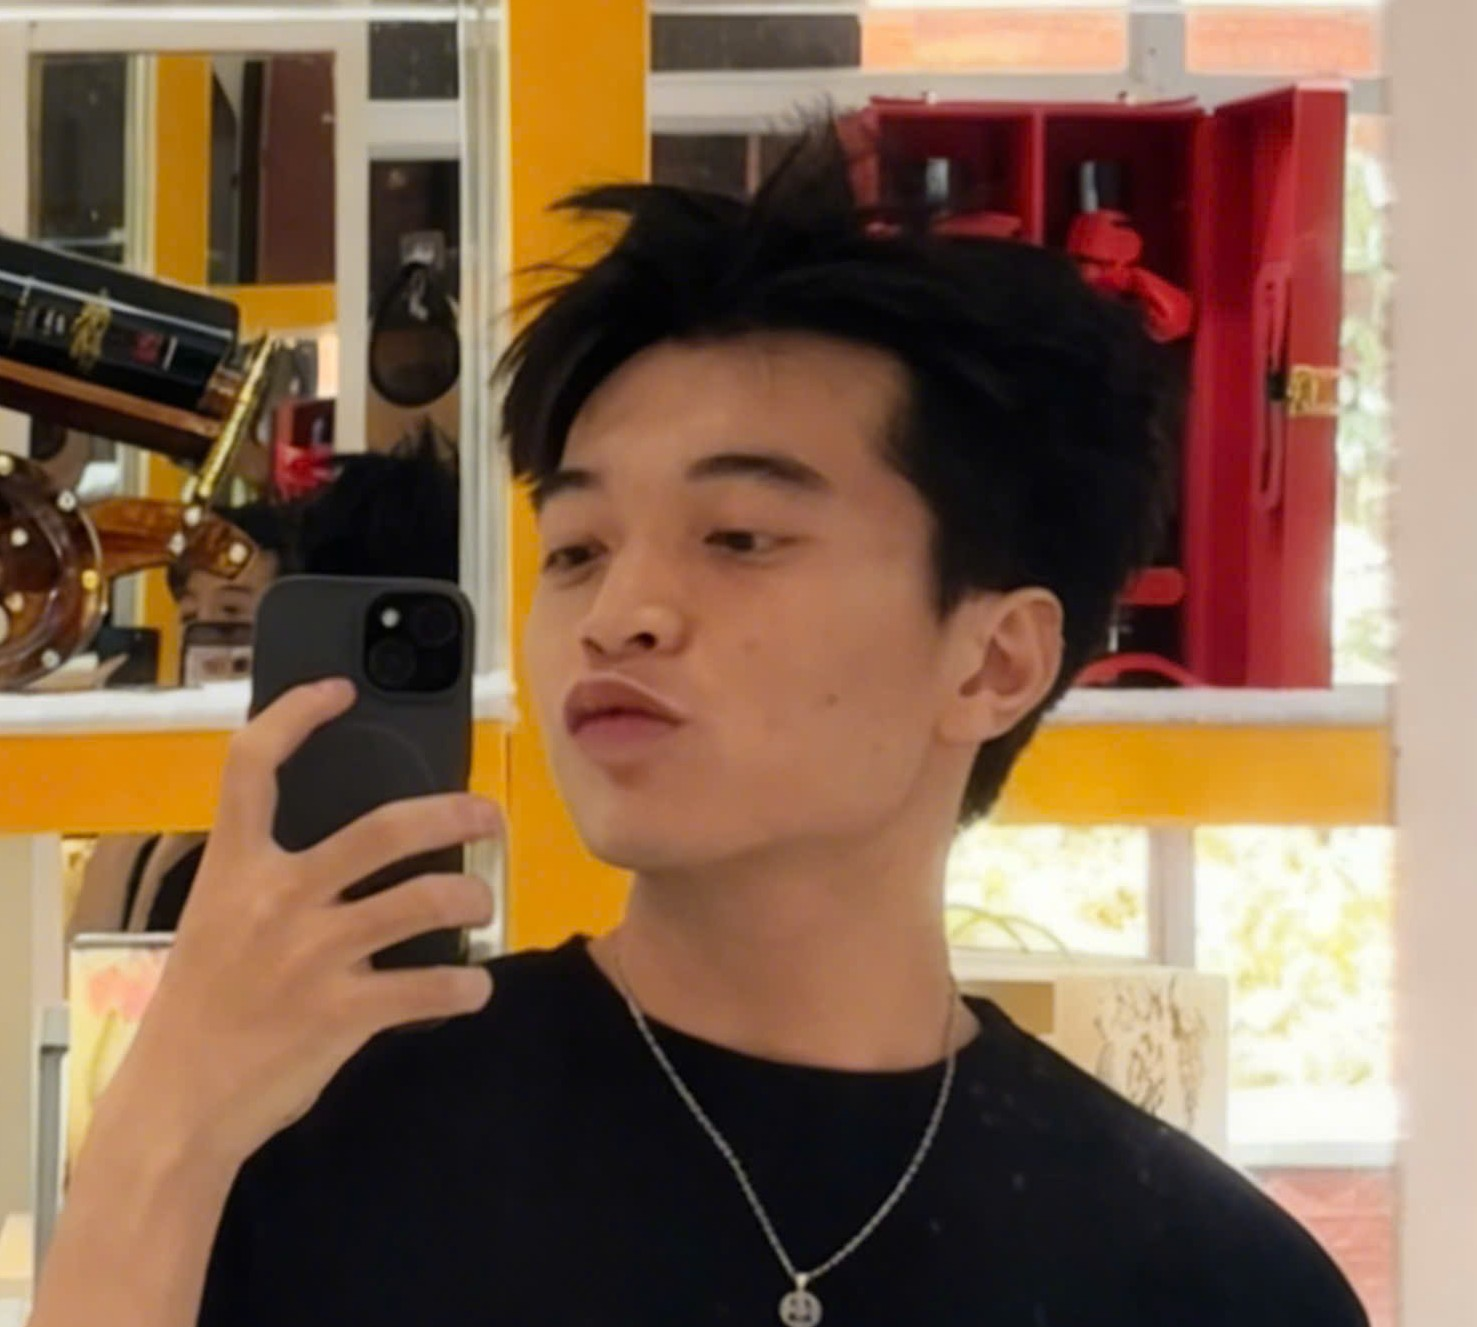

